In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## Handling missing values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [8]:
df["Age"]=2026-df["Year_Birth"]

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
referencee_date = df["Dt_Customer"].max()
df["Customer_Tenure_days"] = (referencee_date - df["Dt_Customer"]).dt.days 

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [11]:
# spending
df["Total_spending"] =df["MntWines"]+df["MntFruits"]+df["MntGoldProds"]+df["MntSweetProducts"]+df["MntFishProducts"]+df["MntMeatProducts"]

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days',
       'Total_spending'],
      dtype='object')

In [13]:
df["Total_children"]=df["Teenhome"]+df["Kidhome"]

In [14]:
df["Education"].value_counts()
# ug,g,pg
df["Education"]=df["Education"].replace({
    "Basic":"undergraduate",
    "Graduation":"Graduate",
    "2n Cycle":"undergraduate",
    "Master":"Postgraduate","PhD":"Postgraduate"})

In [15]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
undergraduate     257
Name: count, dtype: int64

In [16]:
# marital_status
df["Marital_Status"].value_counts()

df["Living_with"] = df["Marital_Status"].replace({
    "Married":"partner",
    "Together":"partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "YOLO":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone"})

In [17]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
df["Living_with"].value_counts()

Living_with
partner    1444
Alone       796
Name: count, dtype: int64

# drop columns

In [19]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,partner


In [22]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines", "MntFruits",
       "MntMeatProducts", "MntFishProducts", "MntSweetProducts",
       "MntGoldProds"]

cols_to_drop = cols+spending_cols
df_cleaned=df.drop(columns=cols_to_drop)

In [23]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days', 'Total_spending',
       'Total_children', 'Living_with'],
      dtype='object')

In [26]:
df_cleaned.shape
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


In [25]:
df.shape

(2240, 27)

# Outliers

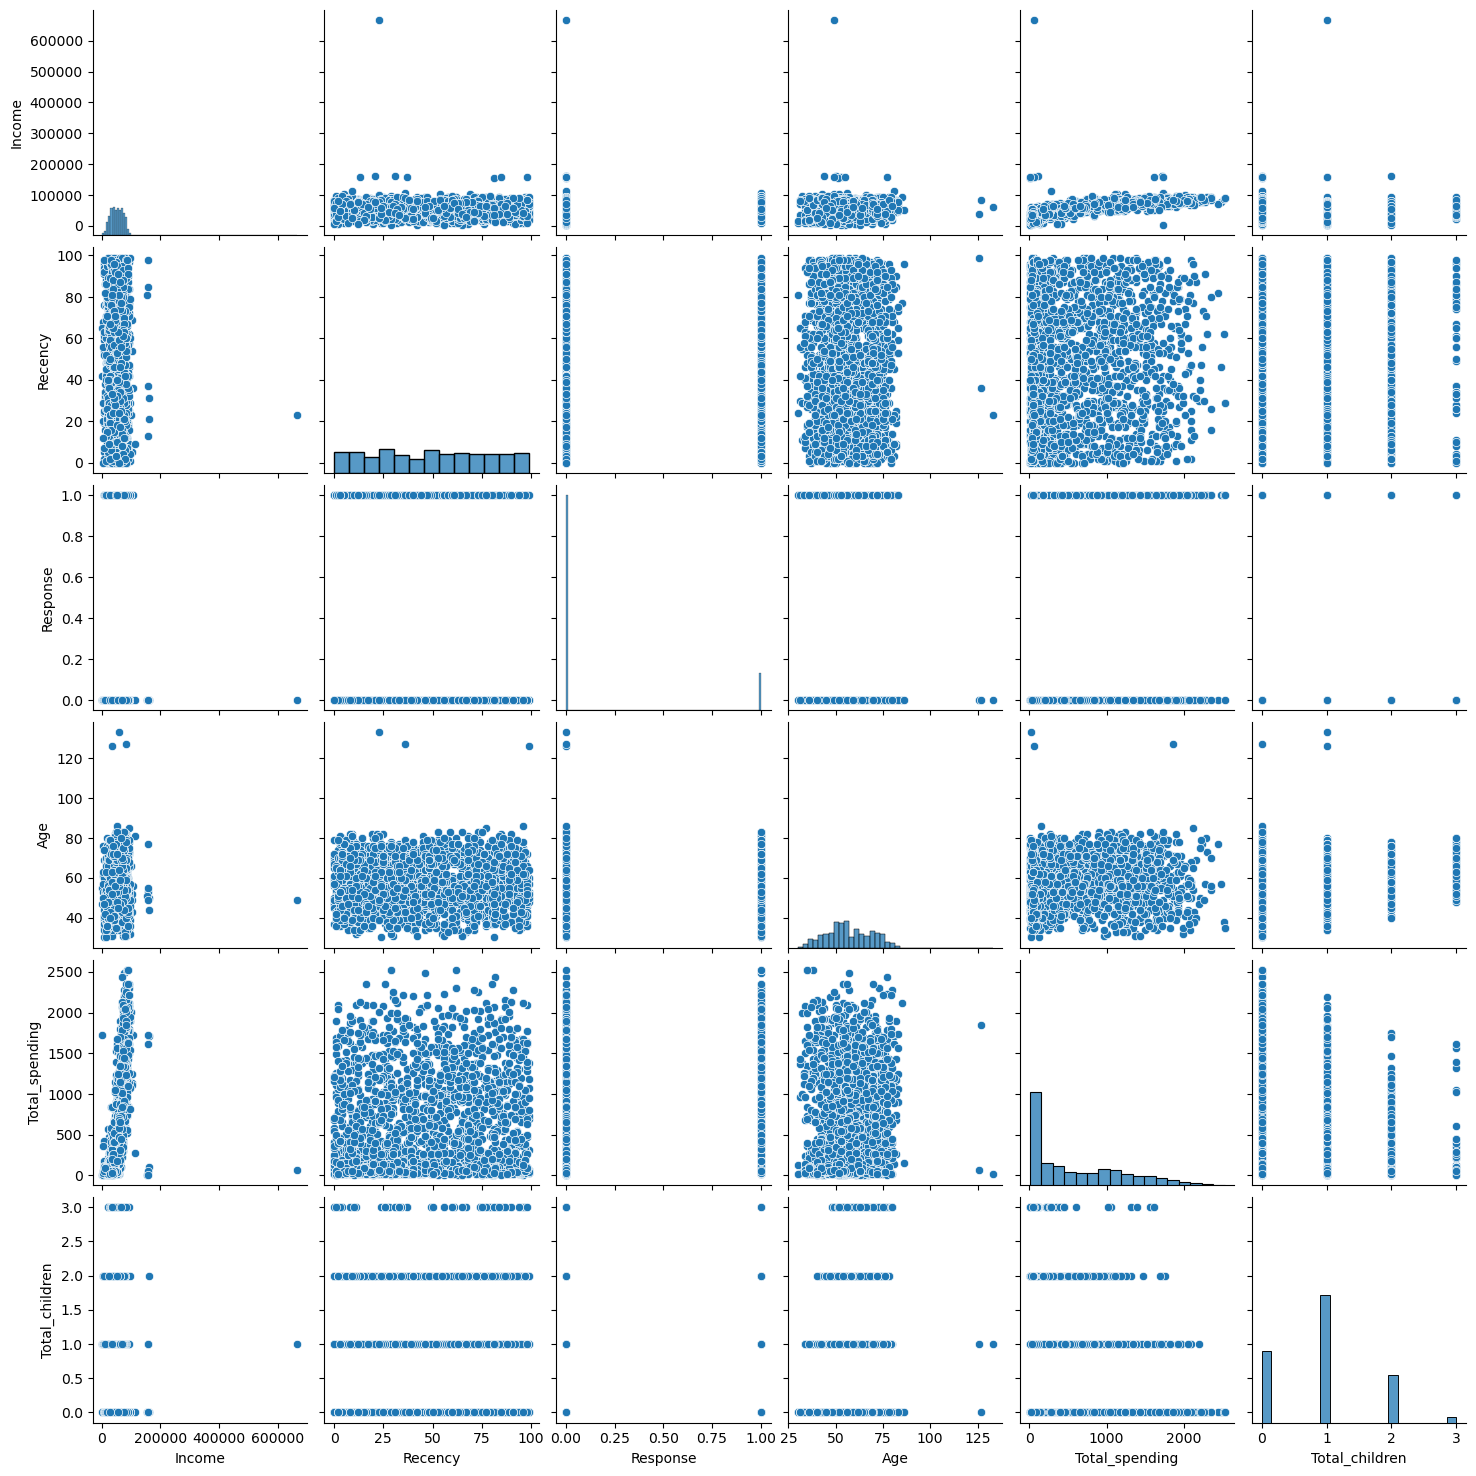

In [29]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_children"]

# relative plots 
sns.pairplot(df_cleaned[cols])

In [31]:
# remove outlier
print("data size with outliers:",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# heatmap

In [32]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

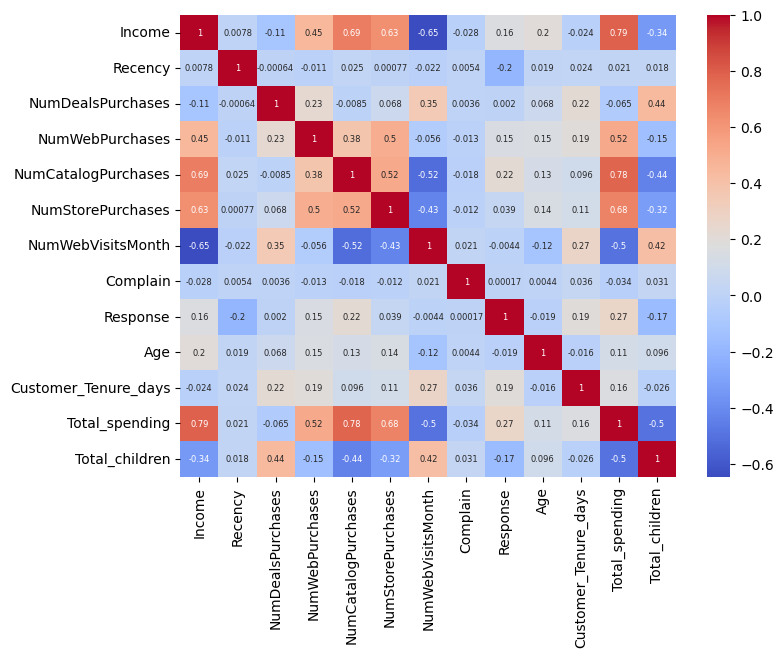

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# encoading


In [36]:
from sklearn.preprocessing import OneHotEncoder

In [41]:
ohe =  OneHotEncoder()
cat_cols=["Education","Living_with"]
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [42]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [43]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_undergraduate,Living_with_Alone,Living_with_partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [44]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [45]:
df_encoded.shape

(2236, 18)

In [46]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_undergraduate,Living_with_Alone,Living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# scaling

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
x = df_encoded

In [49]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(x)

In [50]:
X_scaled.shape

(2236, 18)

In [52]:
# 2d
from sklearn.decomposition import PCA

In [53]:
pca=PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

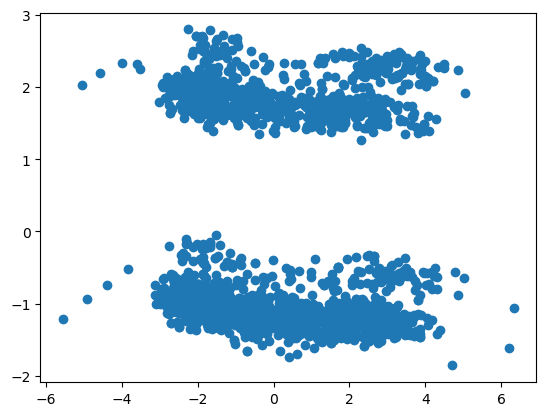

In [57]:
# plot
plt.scatter(X_pca[:,0],X_pca[:,1])

In [60]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [61]:
# 3d
pca=PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [65]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, ' 3D projection')

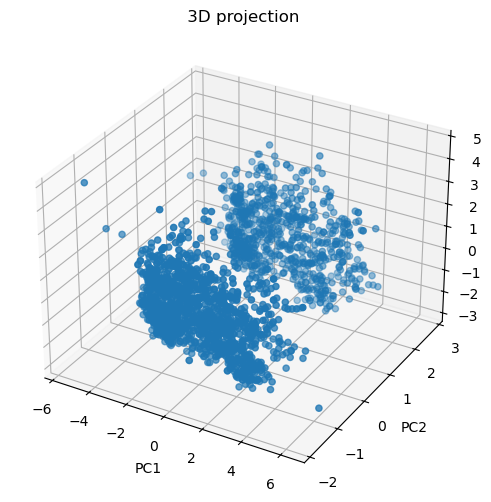

In [67]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title(" 3D projection")

# Analyze k values
## 1.Elbow method

In [69]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k ,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [71]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [73]:
print("best K =",optimal_k)

best K = 4


Text(0, 0.5, 'wcss')

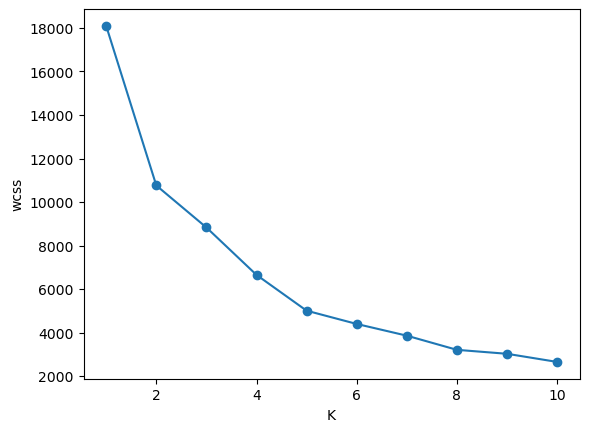

In [75]:
# plot
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

# silhouette score

Text(0, 0.5, 'wcss')

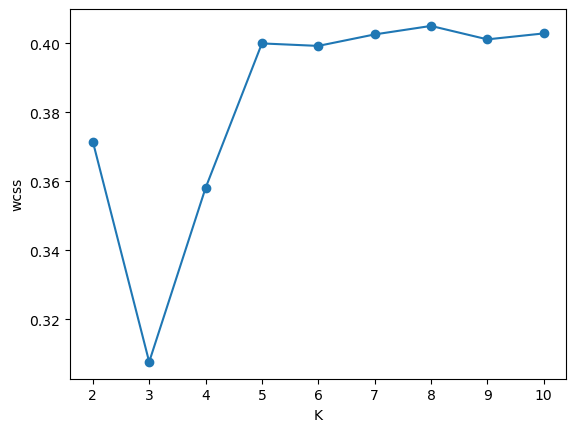

In [80]:
from sklearn.metrics import silhouette_score

scores=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("wcss")


Text(0, 0.5, 'SS')

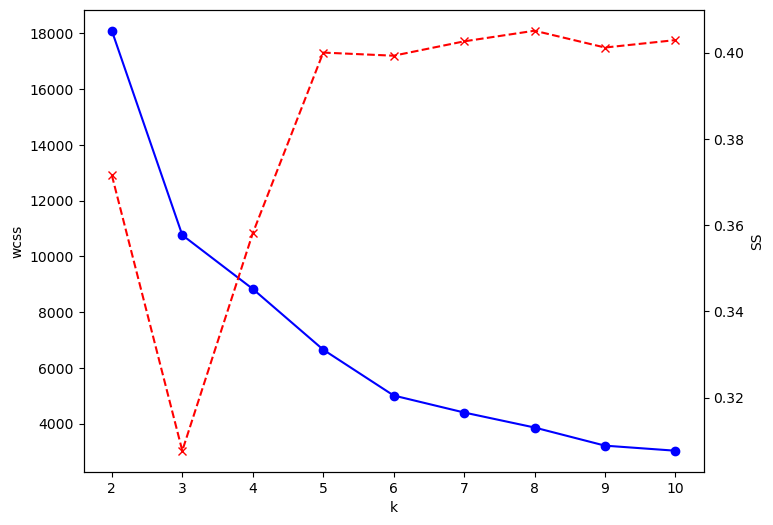

In [86]:
# combine plot of wcss and silhoute
k_range = range(2,11)
fig ,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("SS")

# clustering

In [87]:
kmeans =KMeans(n_clusters=4,random_state=42)
labels_Kmeans = kmeans.fit_predict(X_pca)

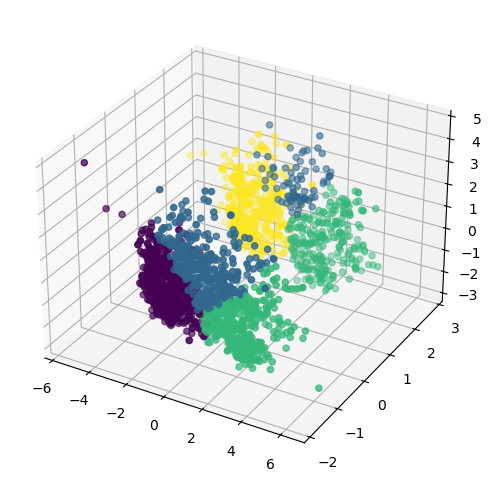

In [89]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_Kmeans)


In [90]:
# agglomerative clustering
from sklearn.cluster import AgglomerativeClustering


In [91]:
agg_clf =AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg =agg_clf.fit_predict(X_pca)

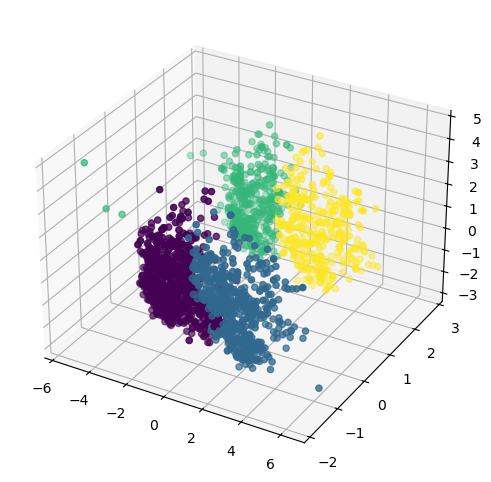

In [93]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

# Characterization of clusters

In [112]:
# df_cleaned.drop("labels",axis=1)
# df_cleaned["clusters"]=labels_agg

x["clusters"]=labels_agg

In [101]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_children,Living_with,labels,clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner,1,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner,0,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner,0,0


<Axes: xlabel='clusters', ylabel='count'>

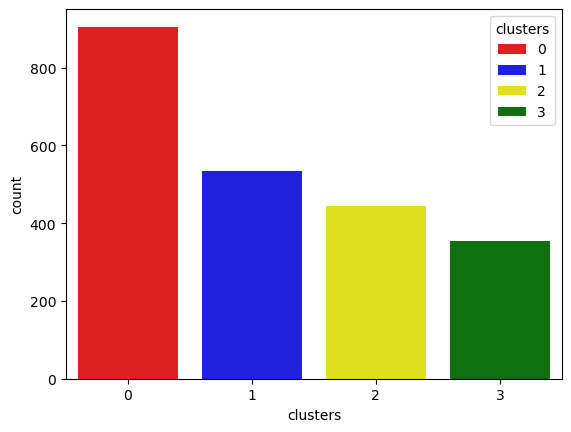

In [113]:
pal =["red","blue","yellow","green"]
# sns.countplot(x=df_cleaned["clusters"],palette=pal,hue=df_cleaned["clusters"])
sns.countplot(x=x["clusters"],palette=pal,hue=df_cleaned["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

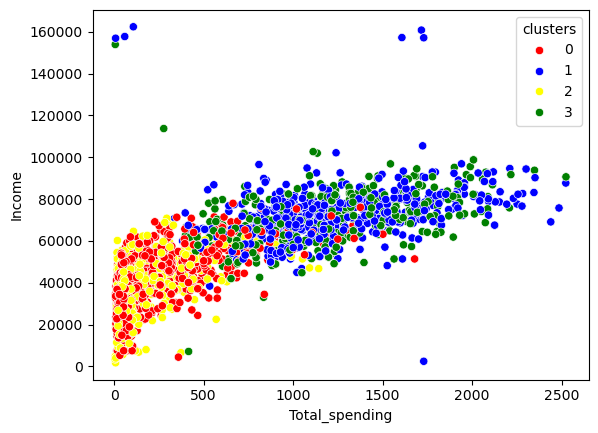

In [114]:
sns.scatterplot(x=x["Total_spending"],y=df_cleaned["Income"],hue=df_cleaned["clusters"],palette=pal)

In [ ]:
# clustr summary
cluster_summary =x.groupby("clusters").mean()
print(cluster_summary)